# Next-diagnosis prediction on a synthetic Delphi-2M-format cohort

This is the walkthrough of my results. Every number is read from a file in `outputs/` or computed in the cell that shows it. The notebook trains nothing and never writes to `outputs/`, and the last cell checks that. The data format follows Delphi-2M. No Delphi code is used.

Reading order: sections 1 to 11 are the main analysis. Sections 15 to 20 test how solid it is. Section 12 lists the limits, section 13 follows one patient, and section 14 says what this means for the role.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from IPython.display import Image, Markdown, display

assert Path("src").is_dir() and Path("outputs").is_dir(), "run this notebook from the repo root"
OUT = Path("outputs")

# analysis_summary.json: every number used by analysis.py's printed summary paragraph
S = json.loads((OUT / "analysis_summary.json").read_text())

# tolerances come from the module that defines them, never retyped here
from src.analysis import _LEAK_TOL, _NLL_TOL


def show_png(name: str) -> None:
    display(Image(filename=str(OUT / name)))


# snapshot of outputs/ to prove at the end that nothing in it was written
_outputs_before = sorted((p.name, p.stat().st_size, p.stat().st_mtime_ns) for p in OUT.iterdir())
print(f"outputs/ snapshot taken: {len(_outputs_before)} files")

outputs/ snapshot taken: 73 files


## 1. What am I predicting, and what counts as good?

Each patient is a sequence of diagnosis tokens, each with an age. At point k the model predicts the next recorded diagnosis from the tokens and ages up to position k-1, never from the age of the target, which would leak the future. Padding and the sex tokens are masked to minus infinity at the output, because they can never be a target.

I count the result as good if the transformer beats the strongest tuned baseline on held-out NLL and per-disease AUROC, holds that in every sex and age group, passes a leakage test that has a positive control, and shows that part of its gain depends on the order of the history. I left out time-to-event prediction and ensembling on purpose.

## 2. Is the data what I think it is?

I load both splits and check the cohort size, the one training patient I drop, and the validation tokens the model never saw in training. I also count same-age ties, because if tied events were stored in token order the model could learn the storage order and nothing about health.

In [2]:
from src.data import build_sequences, load_split, load_vocab
from src.train import _EXCLUDED_TRAIN_PATIENT

train_df = load_split("train")
val_df = load_split("val")
vocab = load_vocab()

print(f"train: {train_df['person_id'].nunique():,} patients, {len(train_df):,} events")
print(f"val:   {val_df['person_id'].nunique():,} patients, {len(val_df):,} events")
print(f"vocab size: {len(vocab)}  (index 0 is padding and never appears in a sequence)")

train: 7,143 patients, 179,390 events
val:   7,143 patients, 179,423 events
vocab size: 997  (index 0 is padding and never appears in a sequence)


In [3]:
sex_indices = {i for i, v in enumerate(vocab) if v in ("Female", "Male")}
p = train_df[train_df["person_id"] == _EXCLUDED_TRAIN_PATIENT].sort_values("age_days")
first_tok = int(p["token"].iloc[0])
n_sex = int(p["token"].isin(sex_indices).sum())
print(f"patient {_EXCLUDED_TRAIN_PATIENT}: {len(p)} events, first token = '{vocab[first_tok]}', sex tokens = {n_sex}")
print("Dropped from every training computation: its first event is not a sex token, so it fails the")
print("sex-token sanity check and the age_sex baseline has nothing to condition on.")

train_df = train_df[train_df["person_id"] != _EXCLUDED_TRAIN_PATIENT]
n_train_patients = train_df["person_id"].nunique()
n_val_patients = val_df["person_id"].nunique()
print(f"train after drop: {n_train_patients:,} patients, {len(train_df):,} events")

patient 402867: 26 events, first token = 'J45 (asthma)', sex tokens = 0
Dropped from every training computation: its first event is not a sex token, so it fails the
sex-token sanity check and the age_sex baseline has nothing to condition on.
train after drop: 7,142 patients, 179,364 events


In [4]:
unseen = set(val_df["token"]) - set(train_df["token"])
n_unseen_events = int(val_df["token"].isin(unseen).sum())
print(f"val tokens absent from train: {len(unseen)}")
print(f"val events carrying an unseen token: {n_unseen_events:,} ({100 * n_unseen_events / len(val_df):.2f}% of val events)")
print("These tokens count against NLL (the model must still spread mass over them) but are excluded from per-disease AUROC.")

val tokens absent from train: 65
val events carrying an unseen token: 96 (0.05% of val events)
These tokens count against NLL (the model must still spread mass over them) but are excluded from per-disease AUROC.


In [5]:
val_sequences = build_sequences(val_df)  # reused in sections 8 and 12
print(f"val sequences built: {len(val_sequences):,} patients")

val sequences built: 7,143 patients


In [6]:
%run check_ties.py

[train] prediction points: 172,222
[train] target has same age as last history event: 225 (0.13%)
[train] among diagnosis-diagnosis ties: ascending token index 120 (53.33%), descending 105 (46.67%)

[val] prediction points: 172,280
[val] target has same age as last history event: 243 (0.14%)
[val] among diagnosis-diagnosis ties: ascending token index 116 (47.74%), descending 127 (52.26%)

vocab diagnosis codes in alphabetical order: False


## 3. What is the model, and how was it trained?

It is a small causal transformer with no positional embedding: a sinusoidal encoding of age is added to each token, so age carries position. I trained it with early stopping on a dev split of the training patients. The validation split played no part in any training or tuning decision.

In [7]:
from src.model import HealthTransformer
import src.train as train_cfg

m = HealthTransformer()
n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"trainable parameters: {n_params:,}")
for name in ("VOCAB_SIZE", "D_MODEL", "N_HEADS", "N_LAYERS", "DROPOUT", "BLOCK_SIZE"):
    print(f"  {name:<11} {getattr(HealthTransformer, name)}")
del m

trainable parameters: 1,065,088
  VOCAB_SIZE  997
  D_MODEL     128
  N_HEADS     4
  N_LAYERS    4
  DROPOUT     0.1
  BLOCK_SIZE  80


In [8]:
print("training configuration (src/train.py):")
for name in ("SEED", "BATCH_SIZE", "LR", "WEIGHT_DECAY", "MAX_EPOCHS", "PATIENCE"):
    print(f"  {name:<13} {getattr(train_cfg, name)}")

training configuration (src/train.py):
  SEED          42
  BATCH_SIZE    64
  LR            0.0003
  WEIGHT_DECAY  0.01
  MAX_EPOCHS    30
  PATIENCE      4


In [9]:
log = pd.read_csv(OUT / "train_log.csv")
display(log)
best = log.loc[log["dev_nll"].idxmin()]
print(
    f"epochs run: {len(log)} of max {train_cfg.MAX_EPOCHS}  |  best dev NLL {best['dev_nll']:.4f} at epoch {int(best['epoch'])}"
    f"  |  total training time {log['elapsed_sec'].sum() / 60:.1f} min"
)

,epoch,train_loss,dev_nll,elapsed_sec
0,1,5.871800,5.564591,11.5
1,2,5.492314,5.450256,10.0
2,3,5.400401,5.387627,7.3
3,4,5.344949,5.348712,8.0
4,5,5.303526,5.320607,7.4
5,6,5.266943,5.297788,7.3
6,7,5.235499,5.284865,7.5
7,8,5.207497,5.270735,7.3
8,9,5.181574,5.261252,7.3
9,10,5.157821,5.255872,7.2


epochs run: 19 of max 30  |  best dev NLL 5.2427 at epoch 15  |  total training time 2.4 min


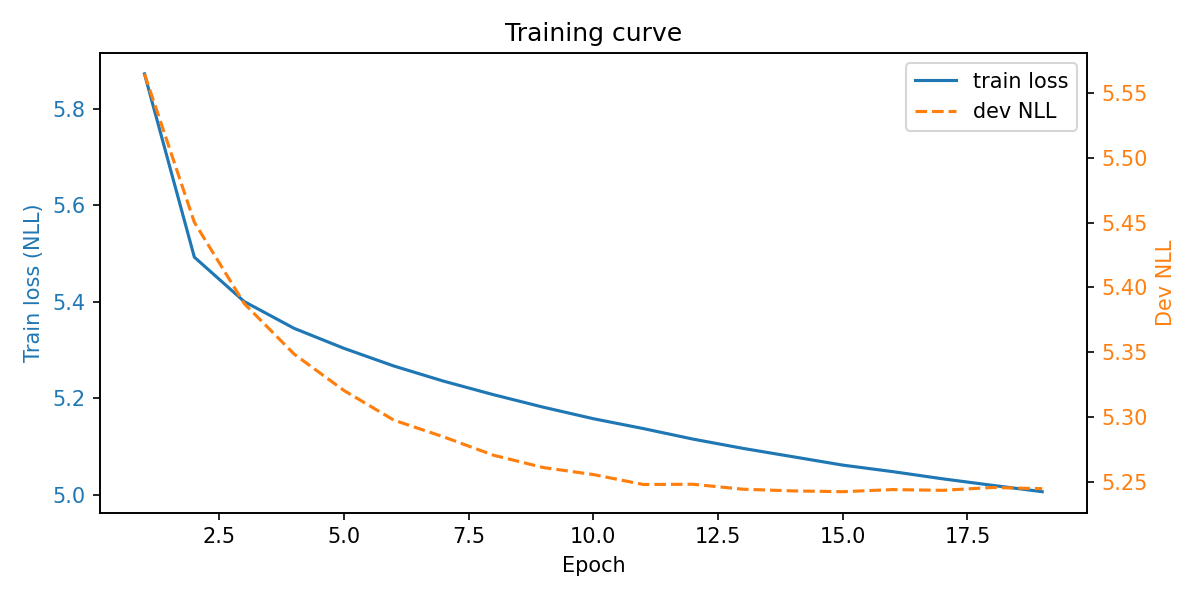

In [10]:
show_png("train_curve.png")

## 4. Does the transformer beat the baselines?

I scored every model with the same protocol in `src/evaluate.py` on the validation split. The marginal baseline uses overall frequency, age_sex adds sex and age band, and bigram uses the previous event, and the last two are blended with the marginal through a constant K tuned on the dev split. Each baseline isolates one source of signal, so I can see which signal the transformer has to beat.

AUROC is computed per disease over all validation prediction points, for diseases with enough validation targets as set in `src/evaluate.py`. It measures how well the model ranks the next recorded diagnosis, not a patient's risk.

In [11]:
mc = pd.read_csv(OUT / "model_comparison.csv")
display(mc.round(4))
print(f"age_sex interpolation constant K = {S['provenance']['age_sex_K']} (argmin dev NLL over age_sex rows of baseline_K_tuning.csv)")

,name,mean_nll,top1_acc,top5_acc,top20_acc,mean_auroc,median_auroc
0,marginal,5.5700,0.0239,0.0997,0.2686,0.5000,0.5000
1,age_sex,5.4190,0.0299,0.1171,0.3069,0.6483,0.6191
2,bigram,5.4675,0.0368,0.1264,0.3081,0.6067,0.5932
3,transformer,5.2508,0.0539,0.1662,0.3614,0.7023,0.6849


age_sex interpolation constant K = 1000 (argmin dev NLL over age_sex rows of baseline_K_tuning.csv)


In [12]:
csv_nll = float(mc.loc[mc["name"] == "transformer", "mean_nll"].iloc[0])
json_nll = float(S["shuffle"]["transformer_unshuffled_nll"])
print(f"model_comparison.csv   transformer mean_nll        = {csv_nll:.6f}")
print(f"analysis_summary.json  transformer_unshuffled_nll  = {json_nll:.6f}")
print(f"|diff| = {abs(csv_nll - json_nll):.2e}   tolerance = {_NLL_TOL:.0e}")
assert abs(csv_nll - json_nll) <= _NLL_TOL, "transformer NLL mismatch between run_eval.py and analysis.py"
print("OK")

model_comparison.csv   transformer mean_nll        = 5.250809
analysis_summary.json  transformer_unshuffled_nll  = 5.250809
|diff| = 0.00e+00   tolerance = 1e-04
OK


## 5. Is the gain spread across diseases?

A mean AUROC can hide a model that wins big on a few common diseases and loses on the rest. So I paired the transformer with age_sex on every eligible disease and counted the wins. In the scatter each point is one disease, and points above the dashed line favour the transformer.

In [13]:
pdp = pd.read_csv(OUT / "per_disease_paired.csv")
n = len(pdp)
n_better = int((pdp["diff"] > 0).sum())
print(f"transformer AUROC > age_sex AUROC on {n_better} of {n} diseases ({100 * n_better / n:.1f}%)")
print(f"mean AUROC difference {pdp['diff'].mean():+.4f}   median {pdp['diff'].median():+.4f}")
assert n == S["per_disease"]["n_diseases"] and np.isclose(n_better / n, S["per_disease"]["frac_better"])
print("matches analysis_summary.json")

transformer AUROC > age_sex AUROC on 454 of 511 diseases (88.8%)
mean AUROC difference +0.0540   median +0.0503
matches analysis_summary.json


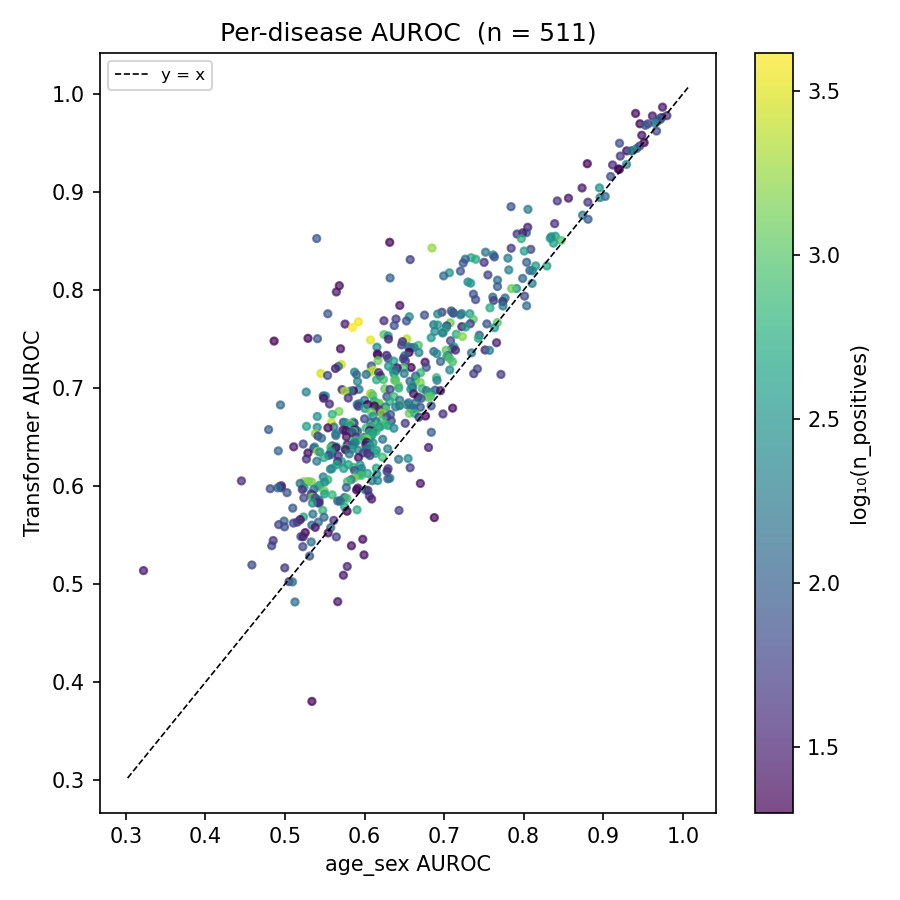

In [14]:
show_png("per_disease_scatter.png")

## 6. Does the gain hold in every group?

I computed mean per-disease AUROC separately within each sex and each age band. A gain that sat in one group only would be a weaker result.

In [15]:
sc = pd.read_csv(OUT / "stratified_comparison.csv")
sc["diff"] = sc["transformer_mean_auc"] - sc["age_sex_mean_auc"]
display(sc[["stratum", "n_diseases", "transformer_mean_auc", "age_sex_mean_auc", "diff"]].round(4))

,stratum,n_diseases,transformer_mean_auc,age_sex_mean_auc,diff
0,Female,506,0.6789,0.6171,0.0618
1,Male,496,0.6672,0.6045,0.0627
2,age<40,462,0.6172,0.5668,0.0505
3,age40-60,506,0.6587,0.5640,0.0947
4,age>60,500,0.6528,0.5942,0.0586


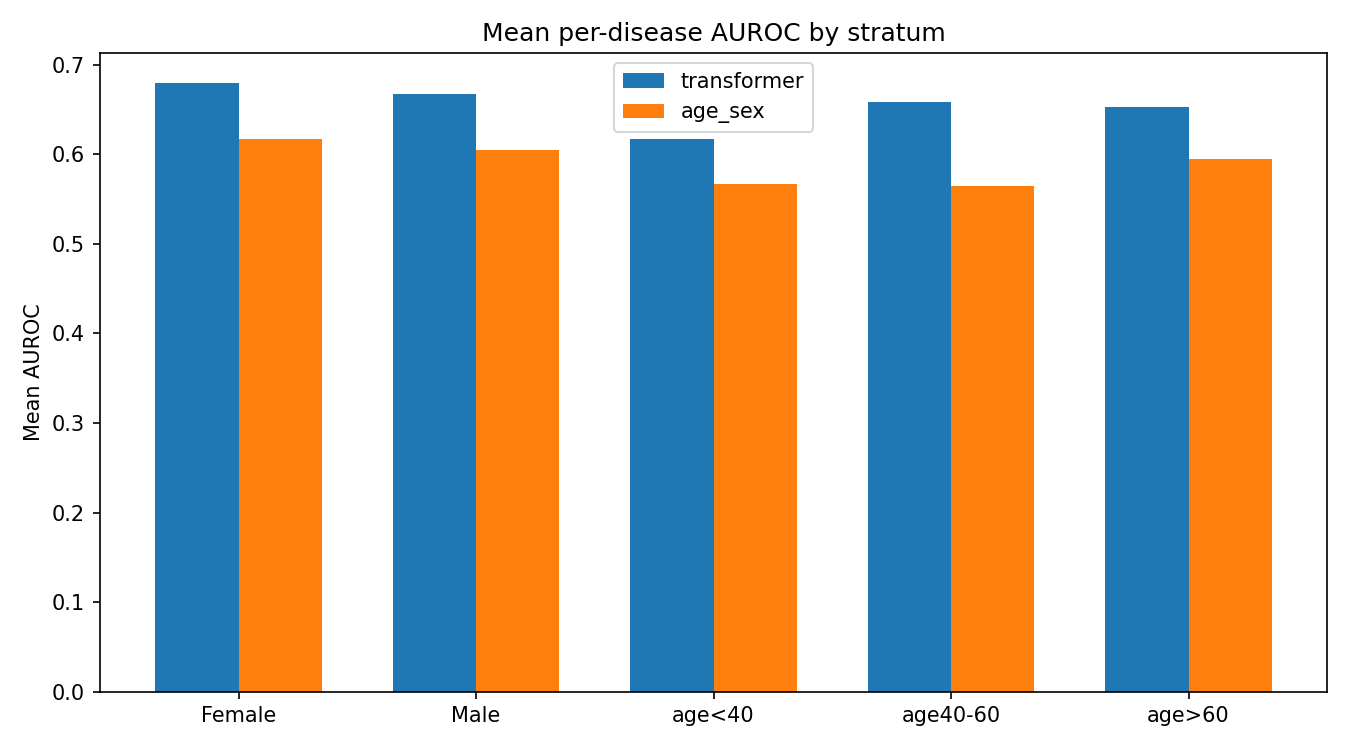

In [16]:
show_png("stratified_bar.png")

## 7. Does the gain depend on the order of the history?

I shuffled the diagnoses within each validation patient and left the sex token and all ages in place. That breaks the order of the diagnoses and the pairing of each diagnosis with its age, but the shuffled history still holds the patient's own diagnoses, including later ones, so co-occurrence survives. The age_sex baseline is the control: its predictions cannot change and only its targets move, so what the transformer loses beyond that points to temporal structure.

In [17]:
sh = S["shuffle"]
shuf = pd.DataFrame(
    [
        {
            "model": m,
            "nll_unshuffled": sh[f"{m}_unshuffled_nll"],
            "nll_shuffled": sh[f"{m}_shuffled_nll"],
            "nll_delta": sh[f"{m}_nll_delta"],
            "auroc_unshuffled": sh[f"{m}_unshuffled_auroc"],
            "auroc_shuffled": sh[f"{m}_shuffled_auroc"],
            "auroc_delta": sh[f"{m}_auroc_delta"],
        }
        for m in ("transformer", "age_sex")
    ]
).set_index("model")
display(shuf.round(4))
print(f"shuffle seed {sh['shuffle_seed']}; identical permutation for both models")

,nll_unshuffled,nll_shuffled,nll_delta,auroc_unshuffled,auroc_shuffled,auroc_delta
model,,,,,,
transformer,5.2508,5.6759,0.4251,0.7023,0.5820,-0.1203
age_sex,5.4190,5.6446,0.2256,0.6483,0.5474,-0.1010


shuffle seed 0; identical permutation for both models


In [18]:
adv = pd.DataFrame(
    {
        "auroc_advantage (transformer minus age_sex)": [
            sh["transformer_unshuffled_auroc"] - sh["age_sex_unshuffled_auroc"],
            sh["transformer_shuffled_auroc"] - sh["age_sex_shuffled_auroc"],
        ],
        "nll_advantage (age_sex minus transformer)": [
            sh["age_sex_unshuffled_nll"] - sh["transformer_unshuffled_nll"],
            sh["age_sex_shuffled_nll"] - sh["transformer_shuffled_nll"],
        ],
    },
    index=["unshuffled", "shuffled"],
)
display(adv.round(4))
print("positive = transformer better, in both columns")

,auroc_advantage (transformer minus age_sex),nll_advantage (age_sex minus transformer)
unshuffled,0.0540,0.1682
shuffled,0.0346,-0.0313


positive = transformer better, in both columns


## 8. Could the model see the future?

A broken causal mask would invalidate every number above. I held the positions up to k-1 fixed, replaced every later token and age with random values, and checked that the logits at k-1 do not move. A test that always passes proves nothing, so the second cell is a positive control: the same change must move the logits at position k, which does see it.

In [19]:
lk = S["leakage"]
print(f"leakage test: {lk['status']}")
print(f"max |logit diff| at k-1 = {lk['max_diff']:.2e}   pass threshold = {_LEAK_TOL:.0e}")
print(f"{lk['n_cases']} cases = {lk['n_patients']} val patients × 3 positions, on {lk['device']}")

leakage test: PASS
max |logit diff| at k-1 = 0.00e+00   pass threshold = 1e-05
150 cases = 50 val patients × 3 positions, on cpu


In [20]:
ckpt = Path(S["provenance"]["checkpoint"])
cpu = torch.device("cpu")
model = HealthTransformer()
model.load_state_dict(torch.load(ckpt, map_location=cpu, weights_only=True))
model.eval()  # dropout off; with dropout on, the two passes would differ by design

BLOCK = HealthTransformer.BLOCK_SIZE
valid_diag = np.array([i for i, v in enumerate(vocab) if v not in ("Female", "Male") and i != 0], dtype=np.int64)

tokens, ages = next((t, a) for t, a in val_sequences if len(t) >= 4)
L = len(tokens)
k = L // 2

tok1 = np.zeros(BLOCK, dtype=np.int64)
age1 = np.zeros(BLOCK, dtype=np.float32)
tok1[:L] = tokens
age1[:L] = ages / 365.25  # days → years, as the model expects

rng = np.random.default_rng(0)
tok2, age2 = tok1.copy(), age1.copy()
tok2[k:L] = rng.choice(valid_diag, size=L - k, replace=True)
age2[k:L] = (float(age1[k - 1]) + np.cumsum(rng.uniform(0.1, 5.0, size=L - k))).astype(np.float32)


def logits(tok: np.ndarray, age: np.ndarray) -> np.ndarray:
    t = torch.from_numpy(tok[None])
    a = torch.from_numpy(age[None])
    with torch.no_grad():
        return model(t, a, key_padding_mask=(t == 0))[0].numpy()


l1, l2 = logits(tok1, age1), logits(tok2, age2)
d_before = float(np.abs(l1[k - 1] - l2[k - 1]).max())
d_at_k = float(np.abs(l1[k] - l2[k]).max())

print(f"patient with L={L} events, k={k}: perturbed tokens[{k}:{L}] and ages[{k}:{L}]")
print(f"max |logit diff| at position k-1 = {d_before:.2e}   expected 0  (sees positions 0..k-1 only)")
print(f"max |logit diff| at position k   = {d_at_k:.2e}   expected > 0 (sees the perturbed token and age at k)")
assert d_before <= _LEAK_TOL, "leak: a future change moved a past logit"
assert d_at_k > _LEAK_TOL, "positive control failed: the perturbation had no visible effect"
print("OK: the test detects a change where one must exist, and none where none may exist")
del model

patient with L=21 events, k=10: perturbed tokens[10:21] and ages[10:21]
max |logit diff| at position k-1 = 0.00e+00   expected 0  (sees positions 0..k-1 only)
max |logit diff| at position k   = 2.08e+00   expected > 0 (sees the perturbed token and age at k)
OK: the test detects a change where one must exist, and none where none may exist


## 9. Does more history help?

I grouped the prediction points by how many events the model had seen and compared both models in each group. Longer histories also belong to older patients, so I read this as a description, and section 12 measures that confound.

In [21]:
hl = pd.read_csv(OUT / "history_length.csv")
order = list(dict.fromkeys(hl["bucket"]))  # bucket order as written in the file
t = hl[hl["model"] == "transformer"].set_index("bucket")
a = hl[hl["model"] == "age_sex"].set_index("bucket")
tab = pd.DataFrame(
    {
        "n_points": t["n_points"],
        "nll_transformer": t["mean_nll"],
        "nll_age_sex": a["mean_nll"],
        "top20_transformer": t["top20_acc"],
        "top20_age_sex": a["top20_acc"],
    }
).loc[order]
tab.index = tab.index.str.replace(chr(0x2013), " to ")  # display only: the file writes bucket ranges with an en dash (U+2013)
display(tab.round(4))

,n_points,nll_transformer,nll_age_sex,top20_transformer,top20_age_sex
bucket,,,,,
1 to 4,28572,5.2078,5.3833,0.3838,0.3450
5 to 9,35715,5.1813,5.3379,0.3773,0.3308
10 to 19,65312,5.2425,5.4040,0.3616,0.3047
20 to 29,30842,5.3318,5.5030,0.3364,0.2722
30+,11839,5.3994,5.6141,0.3227,0.2461


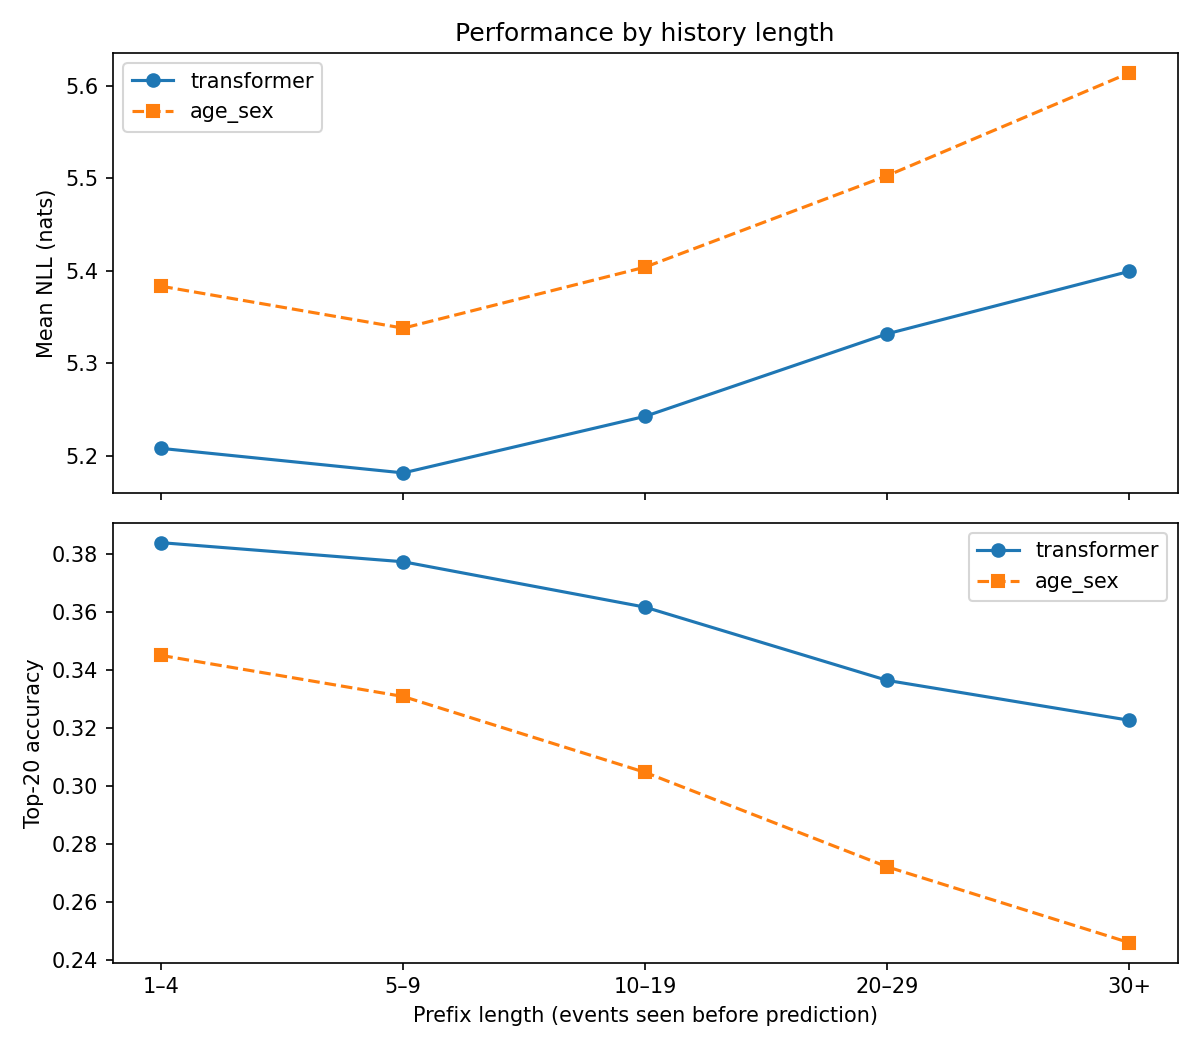

In [22]:
show_png("history_length.png")

## 10. Can the probabilities be trusted?

I compared observed with expected counts per disease, and I binned every prediction by its predicted probability. I do not use pooled ECE as a headline, because almost every prediction is near zero and those bins dominate the number. What matters for use is whether the highest bins are honest.

In [23]:
oe = pd.read_csv(OUT / "calibration_per_disease.csv")
q25, med, q75 = np.percentile(oe["o_e_ratio"], [25, 50, 75])
print(f"per-disease O/E over {len(oe)} diseases: median {med:.4f}, IQR [{q25:.4f}, {q75:.4f}]")
c = S["calibration"]
assert np.isclose(med, c["o_e_median"]) and np.isclose(q25, c["o_e_q25"]) and np.isclose(q75, c["o_e_q75"])
print("matches analysis_summary.json")

per-disease O/E over 511 diseases: median 1.0139, IQR [0.9297, 1.1079]
matches analysis_summary.json


In [24]:
cal = pd.read_csv(OUT / "calibration.csv")
cal["share"] = cal["count"] / cal["count"].sum()
display(cal)
top = cal.loc[cal["count"].idxmax()]
print(f"most populated bin: [{top['lower_edge']:.0e}, {top['upper_edge']:.0e}) holds {100 * top['share']:.1f}% of all {int(cal['count'].sum()):,} pairs")
print(f"pooled ECE (from analysis_summary.json) = {c['ece']:.4f}   over {c['n_bins']} bins, {c['n_diseases']} diseases")

,bin,lower_edge,upper_edge,mean_predicted,observed_rate,count,share
0,0,1.000000e-07,0.000001,8.524318e-07,0.000000,1393,0.000016
1,1,1.000000e-06,0.000010,6.411490e-06,0.000009,1111339,0.012624
2,2,1.000000e-05,0.000100,5.293194e-05,0.000073,16078132,0.182633
3,3,1.000000e-04,0.001000,3.966391e-04,0.000457,40587326,0.461036
4,4,1.000000e-03,0.010000,3.166929e-03,0.003296,27000022,0.306696
5,5,1.000000e-02,0.100000,1.964635e-02,0.018067,3235744,0.036755
6,6,1.000000e-01,1.000000,1.411296e-01,0.106751,21124,0.000240


most populated bin: [1e-04, 1e-03) holds 46.1% of all 88,035,080 pairs
pooled ECE (from analysis_summary.json) = 0.0001   over 7 bins, 511 diseases


In [25]:
hi2 = cal.sort_values("upper_edge", ascending=False).head(2)
print("two highest-probability bins (the main calibration finding):")
for _, r in hi2.iterrows():
    ratio = r["observed_rate"] / r["mean_predicted"] if r["mean_predicted"] > 0 else float("nan")
    print(
        f"  [{r['lower_edge']:.0e}, {r['upper_edge']:.0e})  mean predicted {r['mean_predicted']:.4f}"
        f"  observed {r['observed_rate']:.4f}  observed/predicted {ratio:.3f}  n = {int(r['count']):,}"
    )
print("observed/predicted below 1 = overconfident in that bin; above 1 = underconfident")

two highest-probability bins (the main calibration finding):
  [1e-01, 1e+00)  mean predicted 0.1411  observed 0.1068  observed/predicted 0.756  n = 21,124
  [1e-02, 1e-01)  mean predicted 0.0196  observed 0.0181  observed/predicted 0.920  n = 3,235,744
observed/predicted below 1 = overconfident in that bin; above 1 = underconfident


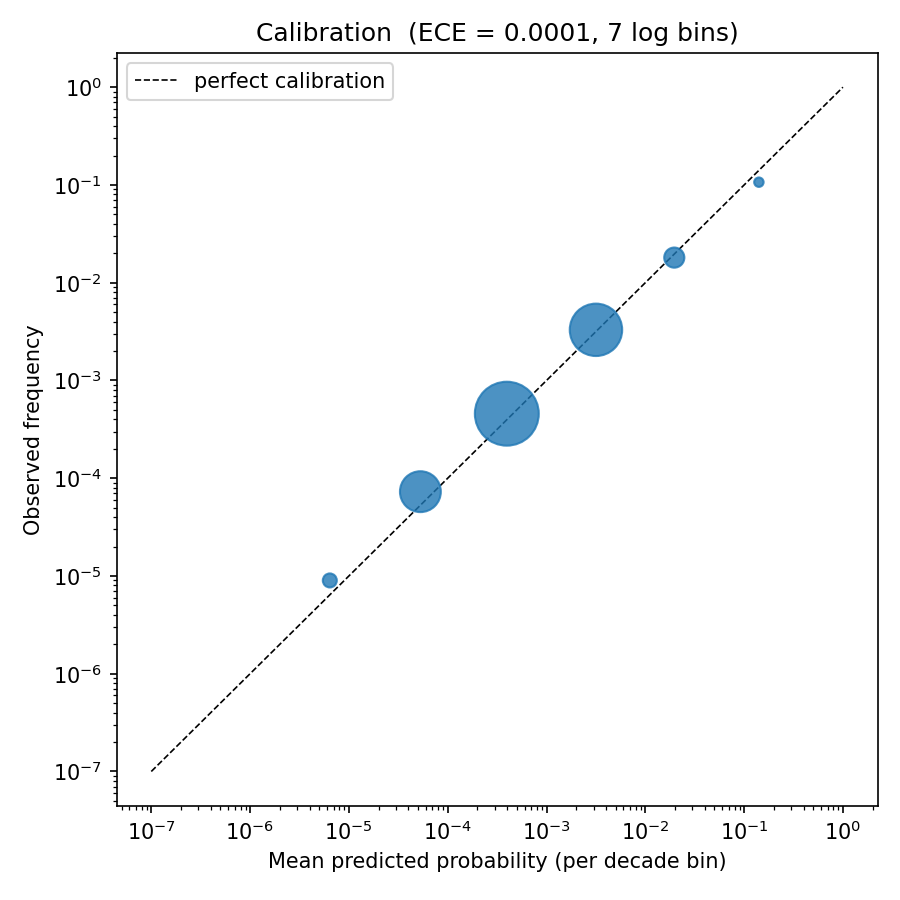

In [26]:
show_png("calibration.png")

## 11. Where does the model fail?

I list the diseases with the lowest transformer AUROC and the ones where it trails age_sex the most, and I mark those in both lists. The scatter sets them against how common each disease is, because a low score on a rare disease is weak evidence.

In [27]:
fl = pd.read_csv(OUT / "failures.csv")
display(fl.round(4))
print(fl["failure_type"].value_counts().to_string())
f = S["failures"]
print(
    f"\n{f['n_failures']} failure-mode diseases  |  lowest transformer AUROC {f['lowest_auc']:.4f}"
    f"  |  bottom-15 AUROC threshold {f['bottom15_auc_threshold']:.4f}  |  worst gap vs age_sex {f['worst_gap']:+.4f}"
)

,disease,auc_transformer,auc_age_sex,diff,n_positives,failure_type
0,L51 (erythema multiforme),0.3804,0.5339,-0.1535,21,both
1,K02 (dental caries),0.4818,0.5125,-0.0307,132,both
2,K06 (other disorders of gingiva and edentulous...,0.4822,0.5663,-0.0841,27,both
3,K11 (diseases of salivary glands),0.5023,0.5095,-0.0072,133,low_auc
4,H49 (paralytic strabismus),0.5026,0.5051,-0.0025,44,low_auc
5,"K09 (cysts of oral region, not elsewhere class...",0.5091,0.5734,-0.0643,28,both
6,G83 (other paralytic syndromes),0.5138,0.3222,0.1916,29,low_auc
7,"C64 Malignant neoplasm of kidney, except renal...",0.5166,0.4997,0.0169,46,low_auc
8,C83 Diffuse non-Hodgkin's lymphoma,0.5180,0.5783,-0.0602,36,both
9,D68 (other coagulation defects),0.5196,0.4584,0.0612,65,low_auc


failure_type
low_auc                  8
underperforms_age_sex    8
both                     7

23 failure-mode diseases  |  lowest transformer AUROC 0.3804  |  bottom-15 AUROC threshold 0.5392  |  worst gap vs age_sex -0.1535


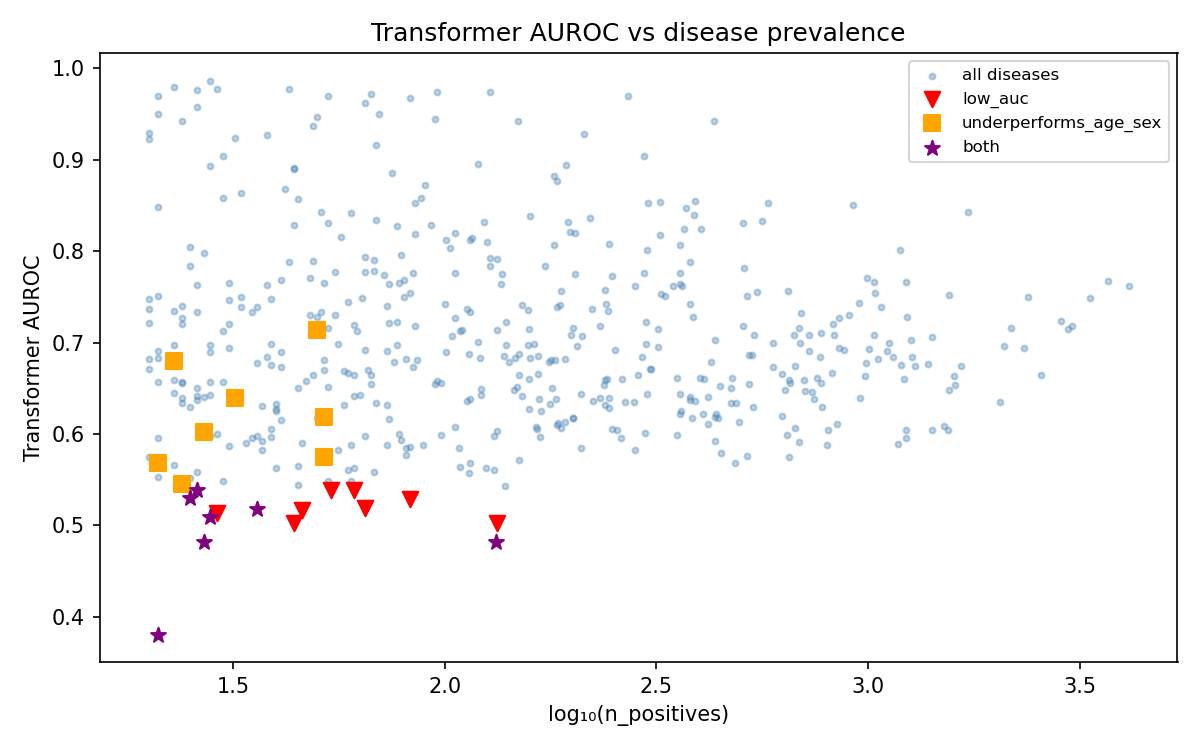

In [28]:
show_png("auc_vs_prevalence.png")

## 12. What are the limits?

Each bullet below takes its numbers from a file or computes them in the cell. The one computation that is new here is a rank correlation between history length and age, which measures the confound in section 9.

In [29]:
# Spearman rank correlation between prefix length k and age at the last history event (position k-1),
# over all val prediction points. pandas rank then Pearson corr on the ranks; no scipy.
ks, ages_last = [], []
for toks, ags in val_sequences:
    L = len(toks)
    if L < 2:
        continue
    ks.append(np.arange(1, L))             # prefix length k = 1..L-1
    ages_last.append(ags[:-1] / 365.25)    # age at position k-1, in years
pts = pd.DataFrame({"prefix_len": np.concatenate(ks), "age_last": np.concatenate(ages_last)})
rho = pts["prefix_len"].rank().corr(pts["age_last"].rank())

min_pos = int(pdp["n_positives"].min())

# Files behind the first four bullets: bootstrap (section 15), panel (section 16), seeds (section 17)
boot = json.loads((OUT / "bootstrap_summary.json").read_text())
panel = pd.read_csv(OUT / "bootstrap_panel.csv")
seeds = pd.read_csv(OUT / "seeds_summary.csv", dtype={"seed": str}).set_index("seed")
seed_ids = [s for s in seeds.index if s not in ("mean", "min", "max")]
n_panel_eligible = int((panel["status"] == "eligible").sum())

display(Markdown(f"""
- **Intervals cover validation sampling for a fixed model.** The intervals in sections 15 and 16 come from
  {boot['n_resamples']:,} resamples of the val patients, scored with one trained model. They show how far a result
  would move with a different validation sample. They do not cover a different training run. The rarest eligible
  disease has {min_pos} positives in val, so estimates for rare diseases stay imprecise.
- **Three seeds give the training spread.** {len(seed_ids)} training runs (seeds {', '.join(seed_ids)}) give a mean
  AUROC from {seeds.loc['min', 'mean_auroc']:.4f} to {seeds.loc['max', 'mean_auroc']:.4f}. That is a spread, not an
  interval. Every other analysis uses the seed {train_cfg.SEED} checkpoint (`{S['provenance']['checkpoint']}`).
- **Panel intervals are not corrected for multiple comparisons.** Section 16 shows {n_panel_eligible} per-disease
  intervals. Each one stands alone. With that many, an interval can exclude zero by chance.
- **K was not retuned per data fraction.** In section 17 the age_sex baseline uses K = {S['provenance']['age_sex_K']}
  at every training fraction. That K was tuned with the full training data. A smaller subset might prefer another K.
- **Synthetic data.** {n_train_patients:,} train and {n_val_patients:,} val patients from a Delphi-2M-style
  generator. The findings describe the generator, not a clinic.
- **History length is confounded with age.** Spearman rank correlation between prefix length and age at the
  last history event over {len(pts):,} val prediction points: **{rho:.3f}**. The history-length curve mixes
  "more context" with "older patient".
- **Shuffled sequences are out of distribution for the transformer.** It was trained on ordered histories;
  its NLL moves from {sh['transformer_unshuffled_nll']:.3f} to {sh['transformer_shuffled_nll']:.3f} under
  shuffling, and part of that is distribution shift rather than lost information.
"""))


- **Intervals cover validation sampling for a fixed model.** The intervals in sections 15 and 16 come from
  1,000 resamples of the val patients, scored with one trained model. They show how far a result
  would move with a different validation sample. They do not cover a different training run. The rarest eligible
  disease has 20 positives in val, so estimates for rare diseases stay imprecise.
- **Three seeds give the training spread.** 3 training runs (seeds 42, 1, 2) give a mean
  AUROC from 0.6999 to 0.7023. That is a spread, not an
  interval. Every other analysis uses the seed 42 checkpoint (`checkpoints/best.pt`).
- **Panel intervals are not corrected for multiple comparisons.** Section 16 shows 16 per-disease
  intervals. Each one stands alone. With that many, an interval can exclude zero by chance.
- **K was not retuned per data fraction.** In section 17 the age_sex baseline uses K = 1000
  at every training fraction. That K was tuned with the full training data. A smaller subset might prefer another K.
- **Synthetic data.** 7,142 train and 7,143 val patients from a Delphi-2M-style
  generator. The findings describe the generator, not a clinic.
- **History length is confounded with age.** Spearman rank correlation between prefix length and age at the
  last history event over 172,280 val prediction points: **0.712**. The history-length curve mixes
  "more context" with "older patient".
- **Shuffled sequences are out of distribution for the transformer.** It was trained on ordered histories;
  its NLL moves from 5.251 to 5.676 under
  shuffling, and part of that is distribution shift rather than lost information.


## 13. What does one prediction look like?

The patient is chosen by the rule printed in the cell, not by me. I show the result whatever it is.

In [30]:
from src.baselines import fit_age_sex
from src.model import make_predict_fn

RULE = (
    "first val patient in file order with at least 10 events whose final event is an "
    "AUROC-eligible disease (eligible = listed in outputs/transformer_per_disease_auc.csv)"
)
print(f"selection rule: {RULE}")

eligible_names = set(pd.read_csv(OUT / "transformer_per_disease_auc.csv")["disease"])

# val_sequences is ordered by ascending person_id (build_sequences sorts), not by file order.
# Map each person_id to its sequence, then walk the ids in order of first appearance in val.bin.
ids_sorted = np.sort(val_df["person_id"].unique())
assert len(ids_sorted) == len(val_sequences)
seq_by_id = dict(zip(ids_sorted.tolist(), val_sequences))

chosen_id = next(
    (
        pid
        for pid in val_df["person_id"].unique().tolist()
        if len(seq_by_id[pid][0]) >= 10 and vocab[int(seq_by_id[pid][0][-1])] in eligible_names
    ),
    None,
)
assert chosen_id is not None, "no val patient satisfies the selection rule"

seq_tokens, seq_ages = seq_by_id[chosen_id]
assert int(seq_tokens[0]) in sex_indices, "chosen patient does not start with a sex token"
hist_tokens, hist_ages = seq_tokens[:-1], seq_ages[:-1]  # everything before the final event
true_tok = int(seq_tokens[-1])                           # the final event is the target
prefix = [(hist_tokens, hist_ages)]                      # same input shape evaluate.py passes

# Transformer: checkpoint on CPU; make_predict_fn puts the model in eval mode
cpu = torch.device("cpu")
tf_model = HealthTransformer()
tf_model.load_state_dict(torch.load(S["provenance"]["checkpoint"], map_location=cpu, weights_only=True))
p_tf = make_predict_fn(tf_model, cpu, vocab)(prefix)[0]

# age_sex: fitted on train minus the excluded patient, with the K recorded by analysis.py
assert not (train_df["person_id"] == _EXCLUDED_TRAIN_PATIENT).any()
K_age_sex = float(S["provenance"]["age_sex_K"])
p_as = fit_age_sex(build_sequences(train_df), vocab, sex_indices, K=K_age_sex)(prefix)[0]

print(f"chosen patient: person_id {chosen_id}, {len(seq_tokens)} events")
print(f"sex: {vocab[int(seq_tokens[0])]}")
print(f"age at last history event: {float(hist_ages[-1]) / 365.25:.2f} years")
print("last 8 history events (age in years, diagnosis):")
for tok, age in zip(hist_tokens[-8:], hist_ages[-8:]):
    print(f"  {float(age) / 365.25:6.2f}  {vocab[int(tok)]}")
print(f"true next diagnosis: {vocab[true_tok]}")


def show_top5_and_rank(name: str, p: np.ndarray) -> None:
    top5 = np.argsort(-p, kind="stable")[:5]
    print(f"\n{name} top 5:")
    for i in top5:
        mark = "   <- true next diagnosis" if int(i) == true_tok else ""
        print(f"  {p[i]:.4f}  {vocab[int(i)]}{mark}")
    n_higher = int((p > p[true_tok]).sum())
    n_equal_others = int((p == p[true_tok]).sum()) - 1
    print(
        f"{name} rank of the true diagnosis: {1 + n_higher}"
        f"  (other tokens with exactly the same probability: {n_equal_others})"
    )


show_top5_and_rank("transformer", p_tf)
show_top5_and_rank(f"age_sex (K={K_age_sex:g})", p_as)
del tf_model

selection rule: first val patient in file order with at least 10 events whose final event is an AUROC-eligible disease (eligible = listed in outputs/transformer_per_disease_auc.csv)
chosen patient: person_id 427993, 21 events
sex: Male
age at last history event: 78.82 years
last 8 history events (age in years, diagnosis):
   71.96  H26 (other cataract)
   72.00  C44 Other malignant neoplasms of skin
   75.33  H11 (other disorders of conjunctiva)
   76.91  M20 (acquired deformities of fingers and toes)
   77.48  K21 (gastro-oesophageal reflux disease)
   77.69  K62 (other diseases of anus and rectum)
   78.43  K51 (ulcerative colitis)
   78.82  L89 (decubitus ulcer)
true next diagnosis: K91 (postprocedural disorders of digestive system, not elsewhere classified)

transformer top 5:
  0.0538  M79 (other soft tissue disorders, not elsewhere classified)
  0.0392  D64 (other anaemias)
  0.0195  J22 (unspecified acute lower respiratory infection)
  0.0193  N39 (other disorders of urinary sys

## 14. What this means for Hurdle

- **A temporal dimension.** The role describes adding "a temporal dimension to Hurdle's predictive models". The shuffle control speaks to that. When I shuffle the order of a patient's diagnoses, the transformer loses more than the age and sex control does. So part of its gain comes from when things happened, beyond which diagnoses the patient has. The size of that part is uncertain, because shuffled histories are out of distribution for the model.
- **Other dated measurements.** The model reads a sequence of tokens, and each token carries an age. Any dated measurement can enter the same age-encoded sequence, such as a biomarker or an omics result. That is one route to what the role calls "fusing with multi-omics data". I have not tested it. This cohort holds diagnoses only.
- **Small and cheap.** The model is small and trains on a laptop.
- **Calibration comes first.** In the highest probability bin the model is overconfident. Calibration must be fixed before any risk use.

## 15. How certain is the headline?

I resampled the validation patients with replacement, keeping each patient's prediction points together, and rescored both models on each resample. The interval covers validation sampling for the one trained model. It does not cover training variance, which section 17 looks at.

In [31]:
boot = json.loads((OUT / "bootstrap_summary.json").read_text())
bm = boot["metrics"]
headline = pd.DataFrame(
    [
        {
            "quantity": label,
            "point": bm[key]["point"],
            "ci95_lo": bm[key]["ci95_lo"],
            "ci95_hi": bm[key]["ci95_hi"],
            "interval_excludes_zero": bm[key]["ci95_lo"] > 0 or bm[key]["ci95_hi"] < 0,
        }
        for label, key in (
            ("NLL difference (age_sex minus transformer)", "nll_diff"),
            ("mean AUROC difference (transformer minus age_sex)", "mean_auroc_diff"),
        )
    ]
).set_index("quantity")
display(headline.round(4))
print("positive = transformer better, in both rows")
print(f"{boot['n_resamples']:,} resamples of {boot['n_val_patients']:,} val patients, seed {boot['seed']}; {boot['interval']}")
sk = boot["skips"]
print(f"disease and resample pairs skipped for lack of a class: {sk['total_disease_resample_pairs_skipped']:,} of {sk['total_disease_resample_pairs']:,}")
ck = boot["correctness_check"]
print(
    "check before resampling, all weights 1, against the committed files:"
    f" max |AUROC diff| {max(ck['max_auc_diff_transformer'], ck['max_auc_diff_age_sex']):.1e},"
    f" max |NLL diff| {max(ck['max_nll_diff_transformer'], ck['max_nll_diff_age_sex']):.1e}"
)

# Share of diseases where the transformer has the higher AUROC: point value only
wins = bm["frac_transformer_higher"]
assert wins["ci95_hi"] < wins["point"], "the stored upper bound is no longer below the point value; revisit the sentence below"
print(f"\nshare of diseases where the transformer has the higher AUROC: {wins['point']:.4f} (point value)")
print(f"percentile bounds stored in the file: {wins['ci95_lo']:.4f} to {wins['ci95_hi']:.4f}")
print(
    "I report no interval for this share. The percentile bootstrap is biased low for a count of wins,"
    " and its upper bound falls below the observed value."
)

,point,ci95_lo,ci95_hi,interval_excludes_zero
quantity,,,,
NLL difference (age_sex minus transformer),0.1682,0.1638,0.1727,True
mean AUROC difference (transformer minus age_sex),0.0540,0.0511,0.0571,True


positive = transformer better, in both rows
1,000 resamples of 7,143 val patients, seed 0; 95 percent percentile interval over resamples of val patients
disease and resample pairs skipped for lack of a class: 0 of 511,000
check before resampling, all weights 1, against the committed files: max |AUROC diff| 2.2e-16, max |NLL diff| 3.1e-08

share of diseases where the transformer has the higher AUROC: 0.8885 (point value)
percentile bounds stored in the file: 0.8376 to 0.8826
I report no interval for this share. The percentile bootstrap is biased low for a count of wins, and its upper bound falls below the observed value.


## 16. Does the gain hold for cardiometabolic disease?

I declared this panel before running anything: ischaemic heart disease, atrial fibrillation, heart failure, cerebrovascular disease and diabetes, as listed in `PANEL_CODES` in `src/bootstrap.py`. Each eligible code gets its own interval for the AUROC difference, from the same resamples as the headline. The intervals are not corrected for multiple comparisons, and codes that are not eligible are listed, not dropped.

In [32]:
panel = pd.read_csv(OUT / "bootstrap_panel.csv")
elig_panel = panel[panel["status"] == "eligible"].copy()
elig_panel["n_positives"] = elig_panel["n_positives"].astype(int)
display(
    elig_panel[["code", "n_positives", "auc_transformer", "auc_age_sex", "diff", "diff_lo", "diff_hi"]]
    .set_index("code")
    .round(4)
)

above = elig_panel["diff_lo"] > 0   # whole interval above zero: transformer higher
below = elig_panel["diff_hi"] < 0   # whole interval below zero: age_sex higher
print(
    f"difference intervals that exclude zero: {int((above | below).sum())} of {len(elig_panel)} eligible codes"
    f"  ({int(above.sum())} with the transformer higher, {int(below.sum())} with age_sex higher)"
)
print("codes whose interval includes zero: " + ", ".join(elig_panel.loc[~(above | below), "code"]))

not_elig = panel[panel["status"] != "eligible"]
print(f"\npanel codes not eligible for AUROC: {len(not_elig)}")
for _, r in not_elig.iterrows():
    n_txt = "" if pd.isna(r["n_positives"]) else f"; {int(r['n_positives'])} positives in val"
    print(f"  {r['code']}: {r['status']} ({r['note']}{n_txt})")

,n_positives,auc_transformer,auc_age_sex,diff,diff_lo,diff_hi
code,,,,,,
I20,1039,0.7546,0.6244,0.1301,0.1132,0.1471
I21,523,0.6864,0.6317,0.0546,0.0350,0.0754
I22,21,0.8487,0.6316,0.2171,0.1116,0.3400
I24,116,0.8144,0.6994,0.1150,0.0673,0.1569
I25,1724,0.8429,0.6847,0.1582,0.1465,0.1692
I48,1420,0.7057,0.6700,0.0358,0.0254,0.0469
I50,508,0.8314,0.7398,0.0916,0.0728,0.1097
I60,58,0.6312,0.6068,0.0244,-0.0407,0.0861
I61,64,0.7483,0.7081,0.0403,-0.0083,0.0844


difference intervals that exclude zero: 12 of 16 eligible codes  (12 with the transformer higher, 0 with age_sex higher)
codes whose interval includes zero: I60, I61, I62, I69

panel codes not eligible for AUROC: 3
  I23: not eligible (not in outputs/transformer_per_disease_auc.csv; 1 positives in val)
  I66: not eligible (not in outputs/transformer_per_disease_auc.csv; 8 positives in val)
  I68: not eligible (not in outputs/transformer_per_disease_auc.csv; 3 positives in val)


## 17. How much do seeds and data size matter?

I trained more seeds on the same data, and further runs on nested subsets of the training patients. Each fraction is a single run, so I read the gaps between fractions against the seed spread. The age_sex baseline is refitted on the same subset with K kept at its full-data value, so its full-fraction row uses the training part only and differs slightly from the headline table.

In [33]:
seeds = pd.read_csv(OUT / "seeds_summary.csv", dtype={"seed": str}).set_index("seed")
display(seeds.round(4))
seed_ids = [s for s in seeds.index if s not in ("mean", "min", "max")]
seed_range = float(seeds.loc["max", "mean_auroc"] - seeds.loc["min", "mean_auroc"])
print(
    f"mean AUROC across {len(seed_ids)} seeds ({', '.join(seed_ids)}): {seeds.loc['min', 'mean_auroc']:.4f}"
    f" to {seeds.loc['max', 'mean_auroc']:.4f}  (range {seed_range:.4f})"
)
print(f"mean NLL across the same seeds: {seeds.loc['min', 'mean_nll']:.4f} to {seeds.loc['max', 'mean_nll']:.4f}")

,mean_nll,top20_acc,mean_auroc,best_epoch
seed,,,,
42,5.2508,0.3614,0.7023,15.0000
1,5.2576,0.3583,0.6999,13.0000
2,5.2547,0.3603,0.7011,15.0000
mean,5.2544,0.3600,0.7011,14.3333
min,5.2508,0.3583,0.6999,13.0000
max,5.2576,0.3614,0.7023,15.0000


mean AUROC across 3 seeds (42, 1, 2): 0.6999 to 0.7023  (range 0.0025)
mean NLL across the same seeds: 5.2508 to 5.2576


model,n_train_patients,transformer,age_sex,gap
fraction,,,,
0.25,1607,0.6507,0.6207,0.0300
0.50,3214,0.6812,0.6363,0.0449
1.00,6428,0.7023,0.6463,0.0560


fraction 0.25: transformer minus age_sex mean AUROC = +0.0300
fraction 0.5: transformer minus age_sex mean AUROC = +0.0449
fraction 1: transformer minus age_sex mean AUROC = +0.0560
seed range of transformer mean AUROC, for scale: 0.0025
age_sex K = 1000 at every fraction, tuned at full data and not retuned


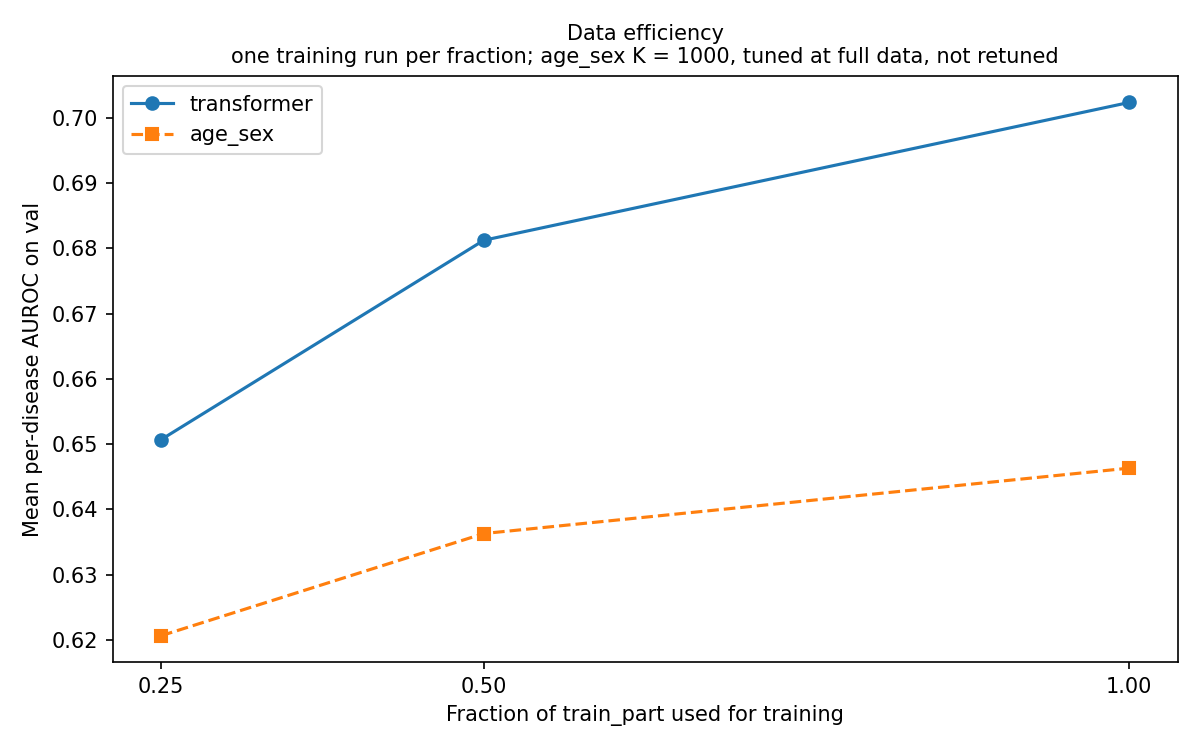

In [34]:
de = pd.read_csv(OUT / "data_efficiency.csv")
eff = de.pivot(index="fraction", columns="model", values="mean_auroc")
eff["gap"] = eff["transformer"] - eff["age_sex"]
eff.insert(0, "n_train_patients", de.groupby("fraction")["n_train_patients"].first())
display(eff[["n_train_patients", "transformer", "age_sex", "gap"]].round(4))

for frac, r in eff.iterrows():
    print(f"fraction {frac:g}: transformer minus age_sex mean AUROC = {r['gap']:+.4f}")
print(f"seed range of transformer mean AUROC, for scale: {seed_range:.4f}")
print(f"age_sex K = {S['provenance']['age_sex_K']} at every fraction, tuned at full data and not retuned")
show_png("data_efficiency.png")

## 18. Do the embeddings group by ICD-10 chapter?

Delphi-2M (Shmatko et al., *Nature* 2025) reported that its diagnosis embeddings group by ICD-10 chapter, so I tested that on my token embeddings. I fixed the method before running it: the codes, the chapter table, the statistic, a label shuffle, a frequency control, an untrained control, and one declared check on diabetes complications. I report the results as they came out.

In [35]:
E = json.loads((OUT / "embedding_chapters.json").read_text())
t1, t2, t3 = E["test1_label_shuffle"], E["test2_frequency_control"], E["test3_negative_control"]

print(f"{E['n_tokens']} codes with at least {E['min_train_count']} train events, in {E['n_chapters']} chapters")
print(f"statistic (within minus between): {E['statistic']:.5f}   within {E['mean_within']:.5f}, between {E['mean_between']:.5f}")
print(f"test 1, label shuffle:      p = {t1['p_value']:.4f}   largest shuffled statistic {t1['null_max']:.5f}")
print(f"test 2, frequency control:  p = {t2['p_value']:.4f}   largest shuffled statistic {t2['null_max']:.5f}")
print(f"smallest p that {E['n_perm']} shuffles can give: {1 / (E['n_perm'] + 1):.4f}")
print(f"test 3, untrained model:    statistic {t3['statistic']:.5f}, p = {t3['p_value']:.4f}")
print(f"untrained statistic as a share of the trained one: {t3['statistic'] / E['statistic']:.2f}")

dc = E["declared_check"]
print()
for code, res in dc["targets"].items():
    if res["status"] == "testable":
        print(f"declared check: {code} is rank {res['rank']} of {dc['n_candidates']} neighbours of {dc['anchor']} (cosine {res['cosine']:.4f})")
    else:
        print(f"declared check: {code} is {res['status']} (fewer than {E['min_train_count']} train events)")

512 codes with at least 20 train events, in 16 chapters
statistic (within minus between): 0.00296   within 0.00078, between -0.00217
test 1, label shuffle:      p = 0.0010   largest shuffled statistic 0.00283
test 2, frequency control:  p = 0.0010   largest shuffled statistic 0.00291
smallest p that 1000 shuffles can give: 0.0010
test 3, untrained model:    statistic 0.00147, p = 0.0539
untrained statistic as a share of the trained one: 0.50

declared check: H36 is rank 158 of 511 neighbours of E11 (cosine 0.0318)
declared check: G63 is not testable (fewer than 20 train events)


In [36]:
nb = pd.read_csv(OUT / "embedding_neighbours.csv")
display(nb[["code", "chapter", "neighbour_rank", "neighbour_code", "neighbour_chapter", "cosine", "same_chapter"]].round(4))
print(f"neighbours in the same chapter as their code: {int(nb['same_chapter'].sum())} of {len(nb)}")

,code,chapter,neighbour_rank,neighbour_code,neighbour_chapter,cosine,same_chapter
0,I10,IX,1,N28,XIV,0.2592,False
1,I10,IX,2,G57,VI,0.2451,False
2,I10,IX,3,I00,IX,0.2372,True
3,M79,XIII,1,I50,IX,0.2688,False
4,M79,XIII,2,B49,I,0.2354,False
5,M79,XIII,3,L24,XII,0.2342,False
6,M25,XIII,1,G25,VI,0.2839,False
7,M25,XIII,2,G44,VI,0.2130,False
8,M25,XIII,3,E11,IV,0.1902,False
9,E78,IV,1,O03,XV,0.2975,False


neighbours in the same chapter as their code: 4 of 30


The grouping is detectable but very small. An untrained model scores about half as much, which is within what shuffled labels give by chance. The declared check did not come out: H36 is not among the near neighbours of E11, and G63 has too few training events to test.

## 19. Why do the failures fail?

I did not test causes. I measured whether age alone, or the previous event alone, carries any signal for each disease, and I compared the failure codes with all eligible diseases. The previous-event measure looks only at the previous event, not the whole history, so these results are descriptive.

In [37]:
from src.failure_why import _MIN_JOINT  # joint count threshold behind max_lift_min5_train

why = pd.read_csv(OUT / "failure_why.csv")
median_dist = float(why["age_distance_val"].median())  # median over all eligible diseases
no_pair = why["max_lift_min5_train"].isna()            # empty = no previous-event pair seen often enough

fail = why[why["in_failures"]]
n_fail = len(fail)
n_fail_no_pair = int(no_pair[fail.index].sum())
share_all_no_pair = float(no_pair.mean())

low = why[why["failure_type"].isin(["low_auc", "both"])]
n_low = len(low)
n_low_below = int((low["age_distance_val"] < median_dist).sum())

under = why[why["failure_type"] == "underperforms_age_sex"]
n_under = len(under)
n_under_above = int((under["age_distance_val"] > median_dist).sum())

print(f"failure codes with no previous-event pair seen at least {_MIN_JOINT} times: {n_fail_no_pair} of {n_fail} ({100 * n_fail_no_pair / n_fail:.1f}%)")
print(f"the same share among all {len(why)} eligible diseases: {100 * share_all_no_pair:.1f}%")
print(f"median age distance over all eligible diseases: {median_dist:.4f}")
print(f"low-AUROC codes (low_auc or both) with below-median age distance: {n_low_below} of {n_low}")
print(f"underperforms_age_sex codes with above-median age distance: {n_under_above} of {n_under}")

# The sentences in the next cell are fixed. These asserts stop the notebook if the files no longer match them.
assert (n_fail_no_pair, n_fail) == (20, 23), f"expected 20 of 23, got {n_fail_no_pair} of {n_fail}"
assert (n_low_below, n_low) == (15, 15), f"expected 15 of 15, got {n_low_below} of {n_low}"
assert (n_under_above, n_under) == (5, 8), f"expected 5 of 8, got {n_under_above} of {n_under}"
print("counts match the fixed sentences below")

failure codes with no previous-event pair seen at least 5 times: 20 of 23 (87.0%)
the same share among all 511 eligible diseases: 29.4%
median age distance over all eligible diseases: 0.1095
low-AUROC codes (low_auc or both) with below-median age distance: 15 of 15
underperforms_age_sex codes with above-median age distance: 5 of 8
counts match the fixed sentences below


In [38]:
show_cols = [
    "failure_type", "n_positives_val", "n_target_train", "auc_transformer", "auc_age_sex", "auc_bigram",
    "age_auroc_val", "age_distance_val", "age_distance_pct", "max_lift_train", "max_lift_n_joint", "max_lift_min5_train",
]
display(why[why["code"].isin(["K02", "K11"])].set_index("code")[show_cols].round(4))

# Fixed sentences. The counts in them were asserted in the cell above.
display(Markdown(f"""
{n_fail_no_pair} of {n_fail} failure codes have no previous-event pair seen at least {_MIN_JOINT} times in train,
against {100 * share_all_no_pair:.1f} percent of all {len(why)} eligible diseases.

All {n_low} low-AUROC codes have a below-median age distance.

{n_under_above} of the {n_under} underperforms_age_sex codes have an above-median age distance.

The failures are consistent with missing signal of the kinds I measured, not with a fault specific to the model.
"""))

,failure_type,n_positives_val,n_target_train,auc_transformer,auc_age_sex,auc_bigram,age_auroc_val,age_distance_val,age_distance_pct,max_lift_train,max_lift_n_joint,max_lift_min5_train
code,,,,,,,,,,,,
K11,low_auc,133,119,0.5023,0.5095,0.5755,0.4577,0.0423,0.2074,24.5296,1,2.5264
K02,both,132,140,0.4818,0.5125,0.5172,0.4723,0.0277,0.1429,24.6031,1,2.2070



20 of 23 failure codes have no previous-event pair seen at least 5 times in train,
against 29.4 percent of all 511 eligible diseases.

All 15 low-AUROC codes have a below-median age distance.

5 of the 8 underperforms_age_sex codes have an above-median age distance.

The failures are consistent with missing signal of the kinds I measured, not with a fault specific to the model.


## 20. Does one temperature fix the overconfidence?

I fitted one temperature on the dev split only and left val untouched. Then I compared calibration on val before and after. A fix tuned on val would flatter itself, so the split matters.

In [39]:
TS = json.loads((OUT / "calibration_tempscaled.json").read_text())
val_b, val_a = TS["val_before"], TS["val_after"]
top_b, top_a = TS["top_bin"]["before"], TS["top_bin"]["after"]
oe_b, oe_a = TS["o_e_before"], TS["o_e_after"]

print(f"T = {TS['temperature']:.2f}, fitted on dev ({TS['dev']['n_patients']:,} patients, {TS['dev']['n_points']:,} prediction points)")
print(f"dev NLL:        at T = 1 {TS['dev']['nll_at_T_1']:.4f}   at the chosen T {TS['dev']['nll_at_T']:.4f}")
print(f"val NLL:        before {val_b['mean_nll']:.4f}   after {val_a['mean_nll']:.4f}")
print(f"val mean AUROC: before {val_b['mean_auroc']:.4f}   after {val_a['mean_auroc']:.4f}")
print(
    f"top bin [{TS['top_bin']['lower_edge']:g}, {TS['top_bin']['upper_edge']:g}) observed/predicted:"
    f" before {top_b['observed_over_predicted']:.3f} over {top_b['count']:,} pairs,"
    f" after {top_a['observed_over_predicted']:.3f} over {top_a['count']:,} pairs"
)
print(f"per-disease O/E before: median {oe_b['median']:.3f}, IQR [{oe_b['q25']:.3f}, {oe_b['q75']:.3f}]")
print(f"per-disease O/E after:  median {oe_a['median']:.3f}, IQR [{oe_a['q25']:.3f}, {oe_a['q75']:.3f}]")
print(f"declared criterion, top bin ratio closer to 1: {'met' if TS['top_bin_ratio_closer_to_1'] else 'not met'}")
print("top-k accuracy cannot change, because temperature keeps the order within each row")

T = 1.05, fitted on dev (714 patients, 17,743 prediction points)
dev NLL:        at T = 1 5.2426   at the chosen T 5.2397
val NLL:        before 5.2508   after 5.2473
val mean AUROC: before 0.7023   after 0.7023
top bin [0.1, 1) observed/predicted: before 0.756 over 21,124 pairs, after 0.892 over 13,549 pairs
per-disease O/E before: median 1.014, IQR [0.930, 1.108]
per-disease O/E after:  median 0.975, IQR [0.872, 1.045]
declared criterion, top bin ratio closer to 1: met
top-k accuracy cannot change, because temperature keeps the order within each row


## Guard: was outputs/ left untouched?

The last cell compares names, sizes and modification times with the snapshot taken at the top.

In [40]:
_outputs_after = sorted((p.name, p.stat().st_size, p.stat().st_mtime_ns) for p in OUT.iterdir())
assert _outputs_after == _outputs_before, "outputs/ changed during this notebook run"
print(f"outputs/ unchanged: {len(_outputs_after)} files")

outputs/ unchanged: 73 files
